# Comparing Performance of Different Exploration Methods

## 📚 Learning Objectives

By completing this notebook, you will:
- Compare different exploration strategies
- Evaluate exploration method performance
- Analyze exploration-exploitation trade-offs
- Visualize comparison results

## 🔗 Prerequisites

- ✅ Understanding of exploration strategies (epsilon-greedy, UCB, Thompson Sampling)
- ✅ Understanding of RL evaluation metrics
- ✅ Python, NumPy, Matplotlib knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 4**:
- Comparing performance of different exploration methods

---

## Introduction

Comparing exploration methods helps identify which strategies work best for different problems and understand the exploration-exploitation trade-off.

## Lesson Brief

This lesson compares multiple exploration methods side by side so students can see their behavior under the same conditions.

The main goal is to move beyond memorizing method names and instead observe practical trade-offs.

Why this matters: comparison notebooks help students build judgment about which method may fit a problem better.

Students should look for differences in speed, stability, and regret.

Teaching note: this notebook compares the methods inside one controlled **bandit-style simulation**. It is a useful comparison, but not an exhaustive statement about all RL environments.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **David Silver - "RL Course Lecture 9: Exploration and Exploitation"**:
[Watch on YouTube](https://www.youtube.com/watch?v=sGuiWX07sKw)

Why this pick:
- Useful when students are comparing strengths, weaknesses, and assumptions.
- Helps them interpret comparison plots with better theory in mind.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Exploration: trying uncertain actions.
- Exploitation: using the current best action.
- Regret: lost reward compared with always choosing the best arm.
- Convergence speed: how quickly a strategy settles near the best action.
- Stability: how noisy or reliable the learning curve looks.

### Quick Check
- Which method improves fastest in this simulation?
- Which method wastes less reward early on?
- Why should students compare regret, not only reward?
- Why does good performance in one bandit simulation not automatically generalize to every RL environment?

### Common Mistakes
- Assuming exploration means permanent randomness.
- Using one lucky run as proof.
- Confusing exploration rate with learning rate.
- Treating one comparison plot as a universal ranking for all RL problems.


## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


## How to Read Comparison Results Carefully

A comparison notebook is useful only if students know what conclusions are safe.

### Safe conclusions

From this notebook, students can say things like:

- one method found the best arm faster in this setup
- one method had lower regret in this setup
- one method looked more stable in this setup

### Unsafe conclusions

Students should **not** say:

- this method is always best for every RL problem
- this plot proves a universal ranking

### Why this warning matters

The current notebook is a controlled bandit-style comparison.
That is excellent for building intuition, but real RL environments add state transitions, delayed effects, and other complications.

So the correct habit is:

`compare carefully, then generalize cautiously.`

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Framework overview: name the strategies and metrics the comparison below really uses.
# Everything promised here is computed in the worked example — nothing stays on paper.

# Load the numeric and plotting libraries used by the comparison.
import numpy as np
import matplotlib.pyplot as plt

# Print the lesson banner.
print("✅ Libraries imported!")
print("\nComparing Exploration Methods Performance")
print("=" * 60)

# The four strategies the worked example trains head-to-head.
print("\nExploration Methods to Compare:")
print("  1. Epsilon-Greedy       (random with probability ε, else greedy)")
print("  2. Upper Confidence Bound (UCB — optimism bonus for rarely-tried arms)")
print("  3. Thompson Sampling    (sample beliefs, act on the sample)")
print("  4. Boltzmann Exploration (softmax over value estimates, taught in lesson 02)")

# The metrics the comparison actually computes and prints.
print("\nComparison Metrics (all computed below):")
print("  - Total reward over all rounds")
print("  - Cumulative regret (shortfall vs always playing the best arm)")
print("  - Best-arm share (fraction of pulls spent on the truly best arm)")
print("  - Convergence behaviour (read from the cumulative-average curves)")

print("\n✅ Comparison framework ready!")


✅ Libraries imported!

Comparing Exploration Methods Performance

Exploration Methods to Compare:
  1. Epsilon-Greedy       (random with probability ε, else greedy)
  2. Upper Confidence Bound (UCB — optimism bonus for rarely-tried arms)
  3. Thompson Sampling    (sample beliefs, act on the sample)
  4. Boltzmann Exploration (softmax over value estimates, taught in lesson 02)

Comparison Metrics (all computed below):
  - Total reward over all rounds
  - Cumulative regret (shortfall vs always playing the best arm)
  - Best-arm share (fraction of pulls spent on the truly best arm)
  - Convergence behaviour (read from the cumulative-average curves)

✅ Comparison framework ready!


## 🌍 Real-World Worked Example — A/B Testing with Multi-Armed Bandits

**Industry context:**
- Netflix shows different thumbnails to different users and picks the best one using Thompson Sampling — same as this example
- Google Ads uses epsilon-greedy to balance showing ads that already work vs. testing new ones
- Booking.com runs 1000+ bandit experiments simultaneously

We compare **ε-greedy**, **UCB**, and **Thompson Sampling** on a real A/B test simulation.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


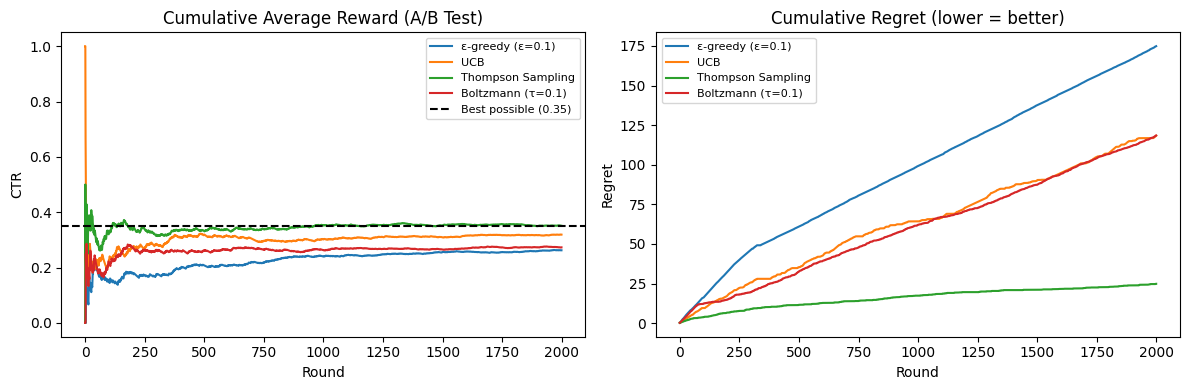

Strategy             | Total reward | Final regret | Best-arm share
--------------------------------------------------------------------
ε-greedy (ε=0.1)     |          525 |        174.9 |          2.5%
UCB                  |          638 |        118.3 |         46.9%
Thompson Sampling    |          702 |         24.8 |         89.9%
Boltzmann (τ=0.1)    |          546 |        118.5 |         55.2%

Highest total reward on THIS run: Thompson Sampling.
One seed is one sample — the ranking of close strategies can change on a rerun;
the regret curves and best-arm shares tell you WHY each strategy earned its total.


In [2]:
# Worked example: four exploration strategies on the SAME 5-variant A/B test.
# Each strategy returns its per-round rewards AND chosen arms, so every metric
# printed at the end is measured from this run — nothing is quoted from a textbook.

np.random.seed(42)

# ── Scenario: 5 website variants (like streaming-service thumbnails) ─────────
# True click-through rates are hidden from the agent; variant 2 is best (35%).
TRUE_RATES = [0.15, 0.22, 0.35, 0.18, 0.28]
N_ARMS = len(TRUE_RATES)
N_ROUNDS = 2000
BEST_ARM = int(np.argmax(TRUE_RATES))
BEST_RATE = max(TRUE_RATES)


def pull(arm):
    """One Bernoulli click with the arm's hidden rate."""
    return 1 if np.random.rand() < TRUE_RATES[arm] else 0


def epsilon_greedy(eps=0.1):
    """Classic ε-greedy: explore uniformly with probability ε, else exploit."""
    counts, totals = np.zeros(N_ARMS), np.zeros(N_ARMS)
    rewards, arms = [], []
    for _ in range(N_ROUNDS):
        # Coin flip decides explore vs exploit this round.
        arm = np.random.randint(N_ARMS) if np.random.rand() < eps \
            else int(np.argmax(totals / (counts + 1e-9)))
        r = pull(arm)
        counts[arm] += 1; totals[arm] += r
        rewards.append(r); arms.append(arm)
    return rewards, arms


def ucb(c=2.0):
    """UCB1: value estimate plus an optimism bonus that shrinks with visits."""
    counts, totals = np.zeros(N_ARMS), np.zeros(N_ARMS)
    rewards, arms = [], []
    for t in range(N_ROUNDS):
        if t < N_ARMS:
            # Play each arm once so every bonus term is defined.
            arm = t
        else:
            ucb_vals = totals / counts + np.sqrt(c * np.log(t + 1) / counts)
            arm = int(np.argmax(ucb_vals))
        r = pull(arm)
        counts[arm] += 1; totals[arm] += r
        rewards.append(r); arms.append(arm)
    return rewards, arms


def thompson():
    """Thompson Sampling with Beta(1,1) priors: sample beliefs, act on the sample."""
    alpha, beta_ = np.ones(N_ARMS), np.ones(N_ARMS)
    rewards, arms = [], []
    for _ in range(N_ROUNDS):
        # One belief sample per arm; play the arm whose sample looks best.
        arm = int(np.argmax(np.random.beta(alpha, beta_)))
        r = pull(arm)
        if r: alpha[arm] += 1
        else: beta_[arm] += 1
        rewards.append(r); arms.append(arm)
    return rewards, arms


def boltzmann(tau=0.1):
    """Boltzmann/softmax exploration (lesson 02): P(arm) ∝ exp(estimate / tau)."""
    counts, totals = np.zeros(N_ARMS), np.zeros(N_ARMS)
    rewards, arms = [], []
    for _ in range(N_ROUNDS):
        # Softmax over current running-mean estimates (max-subtracted for stability).
        q = totals / np.maximum(counts, 1)
        e = np.exp((q - q.max()) / tau)
        arm = int(np.random.choice(N_ARMS, p=e / e.sum()))
        r = pull(arm)
        counts[arm] += 1; totals[arm] += r
        rewards.append(r); arms.append(arm)
    return rewards, arms


# Run all four strategies on the same problem (shared RNG stream, fixed seed above).
strategies = {
    "ε-greedy (ε=0.1)": epsilon_greedy(0.1),
    "UCB": ucb(),
    "Thompson Sampling": thompson(),
    "Boltzmann (τ=0.1)": boltzmann(0.1),
}


def cumavg(lst):
    """Cumulative average — the convergence curve for one strategy."""
    return np.cumsum(lst) / np.arange(1, len(lst) + 1)


# ── Plots: convergence curves and cumulative regret ──────────────────────────
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
for name, (rewards, _) in strategies.items():
    plt.plot(cumavg(rewards), label=name)
plt.axhline(BEST_RATE, color="k", linestyle="--", label=f"Best possible ({BEST_RATE})")
plt.title("Cumulative Average Reward (A/B Test)")
plt.xlabel("Round"); plt.ylabel("CTR"); plt.legend(fontsize=8)

plt.subplot(1, 2, 2)
for name, (_, arms) in strategies.items():
    # Pseudo-regret: expected shortfall of each CHOSEN arm vs the best arm.
    # (Built from the hidden true rates, so it is never negative by luck.)
    chosen_rates = np.array([TRUE_RATES[a] for a in arms])
    plt.plot(np.cumsum(BEST_RATE - chosen_rates), label=name)
plt.title("Cumulative Regret (lower = better)")
plt.xlabel("Round"); plt.ylabel("Regret"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

# ── Metrics table: every number computed from THIS run ───────────────────────
print(f"{'Strategy':<20} | {'Total reward':>12} | {'Final regret':>12} | {'Best-arm share':>14}")
print("-" * 68)
for name, (rewards, arms) in strategies.items():
    total = int(np.sum(rewards))
    # Pseudo-regret over the whole run: how much expected reward the strategy
    # gave up by not always playing the best arm.
    regret = float(np.sum(BEST_RATE - np.array([TRUE_RATES[a] for a in arms])))
    share = float(np.mean(np.array(arms) == BEST_ARM))
    print(f"{name:<20} | {total:>12d} | {regret:>12.1f} | {share:>13.1%}")

# Name this run's winner from the measured totals (a single seed — say so).
winner = max(strategies, key=lambda k: np.sum(strategies[k][0]))
print(f"\nHighest total reward on THIS run: {winner}.")
print("One seed is one sample — the ranking of close strategies can change on a rerun;")
print("the regret curves and best-arm shares tell you WHY each strategy earned its total.")


In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002). *Finite-time Analysis of the Multiarmed Bandit Problem* (UCB1). Machine Learning, 47, 235-256. <https://link.springer.com/article/10.1023/A:1013689704352>
2. Russo, D., Van Roy, B., Kazerouni, A., Osband, I. & Wen, Z. (2018). *A Tutorial on Thompson Sampling*. Foundations and Trends in Machine Learning, 11(1), 1-96. <https://arxiv.org/abs/1707.02038>
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 2, Multi-armed Bandits.
4. Badia, A. P., Piot, B., Kapturowski, S. et al. (2020). *Agent57: Outperforming the Atari Human Benchmark*. ICML. <https://arxiv.org/abs/2003.13350>
"""))

## 📚 References

1. Auer, P., Cesa-Bianchi, N. & Fischer, P. (2002). *Finite-time Analysis of the Multiarmed Bandit Problem* (UCB1). Machine Learning, 47, 235-256. <https://link.springer.com/article/10.1023/A:1013689704352>
2. Russo, D., Van Roy, B., Kazerouni, A., Osband, I. & Wen, Z. (2018). *A Tutorial on Thompson Sampling*. Foundations and Trends in Machine Learning, 11(1), 1-96. <https://arxiv.org/abs/1707.02038>
3. Sutton, R. S. & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. <http://incompleteideas.net/book/the-book-2nd.html> (free online) — see Ch. 2, Multi-armed Bandits.
4. Badia, A. P., Piot, B., Kapturowski, S. et al. (2020). *Agent57: Outperforming the Atari Human Benchmark*. ICML. <https://arxiv.org/abs/2003.13350>


## 📝 Summary

You compared four **exploration strategies** head-to-head on the same bandit problem: ε-greedy (simple, effective), UCB (optimism under uncertainty), Thompson Sampling (Bayesian), and Boltzmann/softmax exploration (temperature-controlled, from lesson 02) — measuring total reward, cumulative regret, and how often each strategy found the truly best arm. The exploration-exploitation tradeoff is central to RL. Real applications: A/B testing at Netflix, ad bidding at Google, recommendation engines at Spotify.

### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


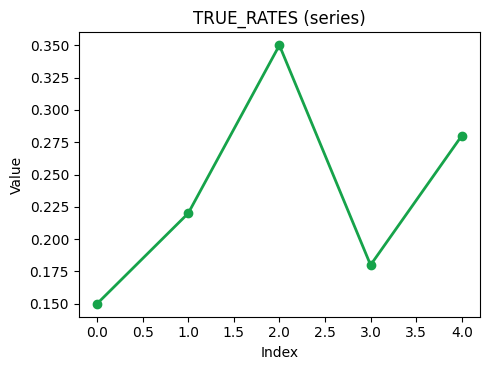

In [4]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Comparing exploration methods reveals that no single strategy is best in every setting; the environment structure matters.

**If students remember one idea:** Method comparison is meaningful only when students explain why one strategy wins under specific conditions.

**Quick check before moving on:**
- Can you explain what the comparison tells you beyond who had the highest final score?
- Can you describe an environment where one exploration method may outperform another?

**Bridge to the next step:** After comparison comes tuning: learning how to set parameters so exploration works well in practice.

Final note: treat the winner here as the winner for **this simulation**, not as a universal champion across all RL tasks.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=8 | term=True | trunc=False


objc[14437]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x111dd8138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1122d49c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[14437]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x111dd8188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1122d4a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[14437]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x111dd7c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1122d4a68). T

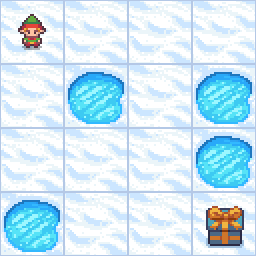

In [5]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
